In [ ]:
import os
import torch
import gc
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/LDMX_GNN/GAIN')

2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 119.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [ ]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sklearn
import inspect

# Load data and setup Graph dataset

In [ ]:
run = 1

In [ ]:
tracker_name = 'Tagger'  # Either 'Tagger' or 'Recoil'

# Read data files
in_dir = '/content/drive/MyDrive/LDMX_GNN/data/inclusive_processed/'
df = GTT.load_pickle_files_to_dataframe(in_dir)

# Currently the ldmx-sw digitization processor outputs full 3D info
# Strip ambiguities must be added manually for consistency with CKF
df = GTT.add_strip_ambiguities(df, tracker_name)

In [ ]:
# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SimParticles_n_primaries'] = df['SimParticles_n_primaries']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']
df_graph['Digi_Edep'] = df[f'{tracker_name}_Digi_Edep']
df_graph['TruthTrack_ID'] = df[f'{tracker_name}_TruthID']
df_graph['TruthTrack_P'] = df[f'{tracker_name}_TruthP']
df_graph['Digi_P'] = df_graph.apply(GTT.map_digi_to_momentum, axis=1)

# Free up some RAM
del df
gc.collect()


/content/drive/MyDrive/LDMX_GNN/GAIN/GNNTrackingTools.py:160: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


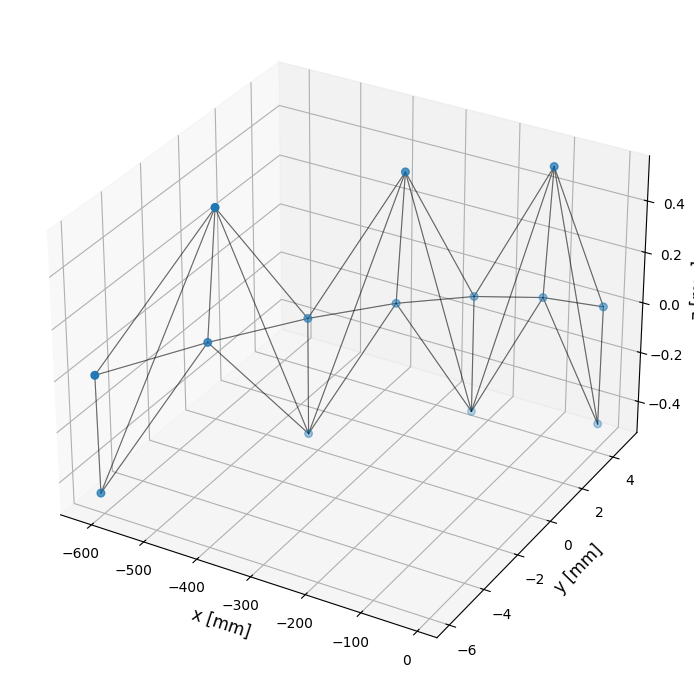

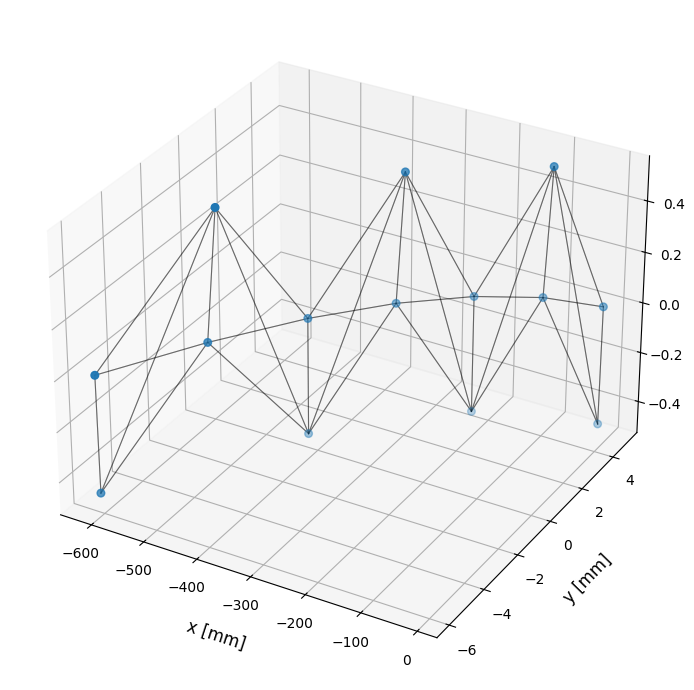

In [ ]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset(df_graph, tracker = tracker_name)

# Plot example graph
data = dataset[1]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [ ]:
# Split into training, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

# Make DataLoaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


/tmp/ipykernel_5088/4059192093.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_5088/4059192093.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_5088/4059192093.py:8: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Initialize Model and Optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Initialize model
hidden_size = 144

model = models.MyIN_5L(hidden_size).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

Total trainable parameters: 796465


In [ ]:
# Initialize optimizer

lr = 5E-4
step_size = 5
gamma = 0.9

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

# Train the model

In [ ]:
epochs = 200

best_val_loss = math.inf
best_thld = None
best_state_dict = None  # or best_model = None

output = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f"---- Epoch {epoch} ----")
    train_loss = GTT.train(model, device, train_loader, optimizer, epoch)
    val_loss = GTT.validate(model, device, val_loader)

    # keep best model (lowest val loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())

    scheduler.step()

    output['train_loss'].append(train_loss)
    output['val_loss'].append(val_loss)


---- Epoch 1 ----
...epoch time: 31.551233768463135s
...epoch 1: train loss=0.5430368445451977
...val loss= 0.5352144932205026
---- Epoch 2 ----
...epoch time: 31.53380584716797s
...epoch 2: train loss=0.5374488263454252
...val loss= 0.5352380492470481
---- Epoch 3 ----
...epoch time: 30.753656148910522s
...epoch 3: train loss=0.5214150336760919
...val loss= 0.3909295479005033
---- Epoch 4 ----
...epoch time: 30.779234170913696s
...epoch 4: train loss=0.3287299164001224
...val loss= 0.3098575682802634
---- Epoch 5 ----
...epoch time: 31.544488191604614s
...epoch 5: train loss=0.2831548543520344
...val loss= 0.26403711939399893
---- Epoch 6 ----
...epoch time: 30.77015447616577s
...epoch 6: train loss=0.24050469284208076
...val loss= 0.22647540305148472
---- Epoch 7 ----
...epoch time: 30.74756360054016s
...epoch 7: train loss=0.20754404886833672
...val loss= 0.1932557120241902
---- Epoch 8 ----
...epoch time: 31.47477674484253s
...epoch 8: train loss=0.1855187336507353
...val loss= 0.1

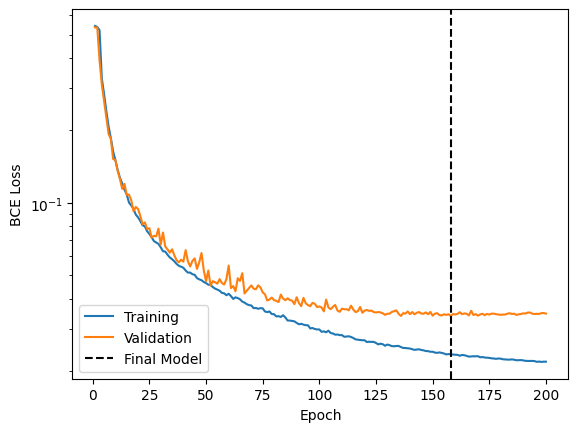

In [ ]:
# convert output to pandas DataFrame
output_df = pd.DataFrame(output)

# Plot the training and validation losses
plt.figure()
plt.plot(np.arange(len(output_df))+1,output_df.train_loss,label='Training')
plt.plot(np.arange(len(output_df))+1,output_df.val_loss,label='Validation')
plt.axvline(x=np.argmin(output_df['val_loss'])+1, linestyle='--', color='k', label='Final Model')

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.yscale('log')
plt.legend()





In [ ]:
# Save the best model state dictionary
torch.save(best_state_dict, '/content/drive/MyDrive/LDMX_GNN/data/state_dicts/IN_amb_large_5L_'+tracker_name+'_state_dict_'+str(run)+'.pt')


In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/LDMX_GNN/data/state_dicts/IN_amb_large_5L_'+tracker_name+'_state_dict_'+str(run)+'.pt'))

test_loss, test_acc, test_TPR, test_TNR, labels, preds = GTT.test(model, device, test_loader)

print("test loss = ", test_loss)
print("test acc = ", test_acc)
print("test TPR = ", test_TPR)
print("test TNR = ", test_TNR)


test loss =  0.035132184963334694
test acc =  0.984300332401082
test TPR =  0.9680796715899219
test TNR =  0.990036254123611


Test AUROC: 0.99906927


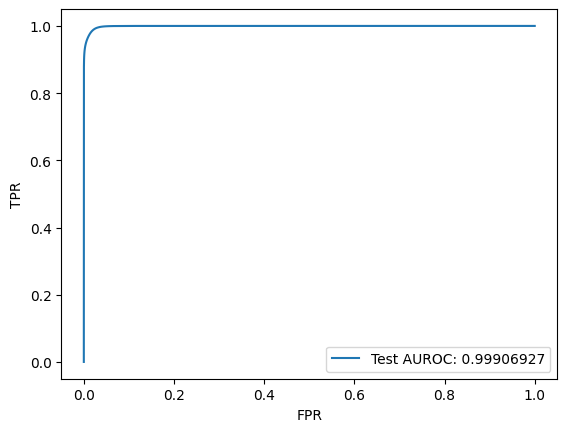

In [ ]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, preds, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.8f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.8f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()